# Set up

In [147]:
!pip install optuna xgboost imbalanced-learn scikit-learn geopy -q

import pandas as pd
import numpy as np
import os
import requests
import time
from datetime import timedelta
from geopy.geocoders import Nominatim
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import optuna
import geopandas as gpd
import joblib
import warnings
from google.colab import drive
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as pl
import shap


optuna.logging.set_verbosity(optuna.logging.WARNING)

# Mount Google Drive
drive.mount('/content/drive')

# Define Global Paths
RAW_DATA_PATH = '/content/drive/MyDrive/Flood_Predictor_Data/floodscan_readme.xlsx'
RAW_COMPILED_PATH = '/content/drive/MyDrive/Flood_Predictor_Data/step2_raw_compiled_data.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Collection

In [5]:
df_raw = pd.read_excel(RAW_DATA_PATH, sheet_name='admin2')
df_nga = df_raw[df_raw['ADM0_NAME'] == 'Nigeria'].copy()
df_nga.head()

,iso3,ADM0_PCODE,ADM0_NAME,ADM1_PCODE,ADM1_NAME,pcode,ADM2_NAME,valid_date,SFED,RP,SFED_BASELINE
565,NGA,NG,Nigeria,NG001,Abia,NG001002,Aba South,2026-05-10,0.000000,1-1.5,0.000000
566,NGA,NG,Nigeria,NG008,Borno,NG008001,Abadam,2026-05-10,0.197503,3-4,0.061787
567,NGA,NG,Nigeria,NG015,Federal Capital Territory,NG015001,Abaji,2026-05-10,0.000617,1-1.5,0.014006
568,NGA,NG,Nigeria,NG003,Akwa Ibom,NG003001,Abak,2026-05-10,0.000000,1-1.5,0.000000
569,NGA,NG,Nigeria,NG011,Ebonyi,NG011001,Abakaliki,2026-05-10,0.000000,1-1.5,0.000378


In [6]:
def extract_spatial_features_from_dataframe(df_nga):

    # Extracting yunique lgas
    if 'ADM2_NAME' in df_nga.columns:
        unique_lgas = df_nga['ADM2_NAME'].dropna().unique()
    else:
        raise KeyError("Column 'ADM2_NAME' not found in df_nga.")

    print(f"Found {len(unique_lgas)} unique LGAs in df_nga. Starting extraction...")

    geolocator = Nominatim(user_agent="nigeria_flood_student_project_v3")
    results = []

    # Urba Keywords
    urban_keywords = ['city', 'town', 'administrative', 'commercial', 'suburb', 'retail', 'residential']

    for i, lga in enumerate(unique_lgas):
        if i % 50 == 0 and i > 0:
            print(f" ... Processed {i}/{len(unique_lgas)} LGAs ...")

        lat, lon, is_urban = None, None, 0
        try:
            query = f"{lga}, Nigeria"
            # addressdetails=True extracts spatial metadata in the same call
            loc = geolocator.geocode(query, addressdetails=True, timeout=10)

            if loc:
                lat, lon = loc.latitude, loc.longitude
                osm_type = loc.raw.get('type', '').lower()
                osm_class = loc.raw.get('class', '').lower()

                if any(kw in osm_type or kw in osm_class for kw in urban_keywords):
                    is_urban = 1
                else:
                    is_urban = 0
        except Exception as e:
            pass

        results.append({
            'ADM2_NAME': lga,
            'Latitude': lat,
            'Longitude': lon,
            'Is_Urban': is_urban
        })

        # API delay
        time.sleep(1.1)

    spatial_df = pd.DataFrame(results)

    # Saving permanently to Google Drive
    output_path = "/content/drive/MyDrive/Flood_Predictor_Data/lga_spatial_lookup.csv"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    spatial_df.to_csv(output_path, index=False)

    print("==================================================")
    print(f" [✓] SUCCESS! Spatial lookup saved to: {output_path}")
    print(" You can now merge this instantly into df_nga using pd.merge()!")
    print("==================================================")
    return spatial_df

if __name__ == "__main__":
    # Assumes df_nga is already loaded in your Colab memory from Step 2
    if 'df_nga' in locals():
        spatial_lookup_df = extract_spatial_features_from_dataframe(df_nga)
    else:
        print("[!] Error: 'df_nga' not found in memory. Please run your data collection cell first.")

Found 755 unique LGAs in df_nga. Starting extraction...
 ... Processed 50/755 LGAs ...
 ... Processed 100/755 LGAs ...
 ... Processed 150/755 LGAs ...
 ... Processed 200/755 LGAs ...
 ... Processed 250/755 LGAs ...
 ... Processed 300/755 LGAs ...
 ... Processed 350/755 LGAs ...
 ... Processed 400/755 LGAs ...
 ... Processed 450/755 LGAs ...
 ... Processed 500/755 LGAs ...
 ... Processed 550/755 LGAs ...
 ... Processed 600/755 LGAs ...
 ... Processed 650/755 LGAs ...
 ... Processed 700/755 LGAs ...
 ... Processed 750/755 LGAs ...
 [✓] SUCCESS! Spatial lookup saved to: /content/drive/MyDrive/Flood_Predictor_Data/lga_spatial_lookup.csv
 You can now merge this instantly into df_nga using pd.merge()!


In [7]:
# 1. Load the spatial lookup table you generated previously
spatial_csv_path = "/content/drive/MyDrive/Flood_Predictor_Data/lga_spatial_lookup.csv"
if os.path.exists(spatial_csv_path):
    print("Loading spatial lookup table...")
    spatial_df = pd.read_csv(spatial_csv_path)
else:
    raise FileNotFoundError(f"[!] Could not find {spatial_csv_path}. Please run the fast geocoder script first.")

# Ensure we are using your existing raw satellite dataset
# Make sure you have `df_nga` loaded in memory or load it from a file
# df_nga = pd.read_csv('your_nigeria_data.csv')

print(f"Initial Rows in Satellite Data: {len(df_nga)}")

# 2. Merge the coordinates and LULC (Is_Urban) into the main dataset
# We use a LEFT merge so we keep all flood records, just adding the coordinates
df_merged = pd.merge(df_nga, spatial_df, left_on='ADM2_NAME', right_on='ADM2_NAME', how='left')

# 3. Standardize core columns
# Rename columns if needed to match downstream scripts
# e.g., if date column is named 'Date', change it to 'valid_date'

# Define columns you want to retain (Add or remove based on your dataset)
cols_to_keep = [
    'ADM1_NAME', 'ADM2_NAME', 'valid_date', 'Latitude', 'Longitude',
    'SFED', 'SFED_BASELINE', 'Is_Urban', 'RP'
]
# Only keep columns that actually exist to prevent KeyErrors
cols_to_keep = [c for c in cols_to_keep if c in df_merged.columns]
df_cleaned = df_merged[cols_to_keep]

# 4. Drop rows with missing critical spatial coordinates
initial_len = len(df_cleaned)
df_cleaned = df_cleaned.dropna(subset=['Latitude', 'Longitude']).reset_index(drop=True)
print(f"Cleaned Rows: {len(df_cleaned)} (Dropped {initial_len - len(df_cleaned)} rows due to missing coordinates)")

Loading spatial lookup table...
Initial Rows in Satellite Data: 67729
Cleaned Rows: 66750 (Dropped 979 rows due to missing coordinates)


In [12]:
print("--- Starting Advanced Batch Meteorological Extraction ---")

# 1. Convert dates to standard format
df_cleaned['valid_date'] = pd.to_datetime(df_cleaned['valid_date'])

# 2. Find unique LGAs to process
unique_locations = df_cleaned[['ADM2_NAME', 'Latitude', 'Longitude']].drop_duplicates()

# ---> HACKATHON SPEED TEST <---
# Uncomment the line below to only process 3 LGAs to ensure it works fast before doing all 700+
# unique_locations = unique_locations.head(3)

print(f"Fetching massive historical weather blocks for {len(unique_locations)} locations...")

all_weather_dfs = []
url = "https://archive-api.open-meteo.com/v1/archive"

# Initialize tqdm around our loop to generate a beautiful progress bar!
for idx, row in tqdm(unique_locations.iterrows(), total=len(unique_locations), desc="API Progress"):

    # Find the earliest and latest dates we need for this specific LGA
    lga_data = df_cleaned[df_cleaned['ADM2_NAME'] == row['ADM2_NAME']]
    min_date = lga_data['valid_date'].min() - timedelta(days=30) # 30 days prior for API decay math
    max_date = lga_data['valid_date'].max()

    start_str = min_date.strftime('%Y-%m-%d')
    end_str = max_date.strftime('%Y-%m-%d')

    # THE "GOD-MODE" PARAMETERS
    params = {
        "latitude": row['Latitude'], "longitude": row['Longitude'],
        "start_date": start_str, "end_date": end_str,
        "daily": [
            "precipitation_sum",
            "precipitation_hours",           # For Intensity
            "weather_code",                  # For Thunderstorms
            "et0_fao_evapotranspiration",    # Evaporation
            "soil_moisture_0_to_7cm_mean",   # Surface Soil
            "soil_moisture_7_to_28cm_mean",  # Deep Soil
            "soil_temperature_0_to_7cm_mean" # Topsoil Baking
        ],
        "timezone": "Africa/Lagos"
    }

    try:
        res = requests.get(url, params=params, timeout=15).json()

        # Catch all the new variables
        mini_df = pd.DataFrame({
            'valid_date': pd.to_datetime(res['daily']['time']),
            'Daily_Rain': res['daily']['precipitation_sum'],
            'Daily_Rain_Hours': res['daily']['precipitation_hours'],
            'Weather_Code': res['daily']['weather_code'],
            'Daily_Evapo': res['daily']['et0_fao_evapotranspiration'],
            'Daily_Soil_Surface': res['daily']['soil_moisture_0_to_7cm_mean'],
            'Daily_Soil_Deep': res['daily']['soil_moisture_7_to_28cm_mean'],
            'Daily_Soil_Temp': res['daily']['soil_temperature_0_to_7cm_mean']
        })
        mini_df['ADM2_NAME'] = row['ADM2_NAME']
        mini_df['Elevation_m'] = res.get('elevation', 50.0)

        mini_df.fillna(0, inplace=True)

        # --- CALCULATE TIME-LAGGED MATH LOCALLY ---

        # Standard Lags
        mini_df['Past_3D_Rainfall_mm'] = mini_df['Daily_Rain'].rolling(3).sum().shift(1)
        mini_df['Past_7D_Rainfall_mm'] = mini_df['Daily_Rain'].rolling(7).sum().shift(1)
        mini_df['Past_14D_Rainfall_mm'] = mini_df['Daily_Rain'].rolling(14).sum().shift(1)
        mini_df['Past_30D_Rainfall_mm'] = mini_df['Daily_Rain'].rolling(30).sum().shift(1)
        mini_df['Past_7D_Soil_Moisture'] = mini_df['Daily_Soil_Surface'].rolling(7).mean().shift(1)
        mini_df['Prior_4D_Soil_Moisture'] = mini_df['Daily_Soil_Surface'].rolling(4).mean().shift(4)

        # New Advanced Lags
        mini_df['Past_7D_Deep_Soil'] = mini_df['Daily_Soil_Deep'].rolling(7).mean().shift(1)
        mini_df['Past_7D_Evapo'] = mini_df['Daily_Evapo'].rolling(7).sum().shift(1)

        # Rainfall Intensity (mm per hour) - avoid dividing by zero
        mini_df['Daily_Intensity'] = np.where(mini_df['Daily_Rain_Hours'] > 0,
                                              mini_df['Daily_Rain'] / mini_df['Daily_Rain_Hours'], 0)
        mini_df['Past_3D_Intensity'] = mini_df['Daily_Intensity'].rolling(3).mean().shift(1)

        # Thunderstorm Tracker (WMO Codes 95+ are severe thunderstorms)
        mini_df['Thunderstorm_Yesterday'] = mini_df['Weather_Code'].shift(1).apply(lambda x: 1 if x >= 95 else 0)

        # Drop the raw daily columns to save massive amounts of RAM
        mini_df.drop(columns=[
            'Daily_Rain', 'Daily_Rain_Hours', 'Weather_Code', 'Daily_Evapo',
            'Daily_Soil_Surface', 'Daily_Soil_Deep', 'Daily_Soil_Temp', 'Daily_Intensity'
        ], inplace=True)

        all_weather_dfs.append(mini_df)

    except Exception as e:
        # Pass silently, tqdm will keep moving
        pass

    time.sleep(0.5)

# 3. Merge API data into our main cleaned dataframe
print("\nAssembling master calendar and merging...")
weather_master = pd.concat(all_weather_dfs, ignore_index=True)
df_compiled = pd.merge(df_cleaned, weather_master, on=['ADM2_NAME', 'valid_date'], how='inner')

# Clean up nulls created by rolling windows (the first 30 days of data per LGA)
df_compiled = df_compiled.dropna().reset_index(drop=True)

# Save the final dataset ready for Feature Engineering!
output_path = "/content/drive/MyDrive/Flood_Predictor_Data/step4_meteorological_data_advanced.csv"
df_compiled.to_csv(output_path, index=False)
print(f"[✓] Data Collection Complete. Raw file saved to {output_path}")

--- Starting Advanced Batch Meteorological Extraction ---
Fetching massive historical weather blocks for 744 locations...


API Progress: 100%|██████████| 744/744 [28:04<00:00,  2.26s/it]



Assembling master calendar and merging...
[✓] Data Collection Complete. Raw file saved to /content/drive/MyDrive/Flood_Predictor_Data/step4_meteorological_data_advanced.csv


In [21]:
print("--- Starting Hydrological Spatial Calculation ---")

# 1. Load the meteorological dataset we just built
input_path = "/content/drive/MyDrive/Flood_Predictor_Data/step4_meteorological_data_advanced.csv"
print(f"Loading weather dataset from {input_path}...")
df = pd.read_csv(input_path)

# 2. Extract ONLY the unique locations.
# We don't want to calculate the same LGA's river distance 90 times!
unique_locations = df[['ADM2_NAME', 'Latitude', 'Longitude']].drop_duplicates().copy()
print(f"Found {len(unique_locations)} unique LGAs. Preparing spatial math...")

# 3. Load the River Map (Update this path to your exact file name!)
# It can be a .geojson or a .shp file.
river_file_path = "/content/drive/MyDrive/Flood_Predictor_Data/export.geojson"

if not os.path.exists(river_file_path):
    raise FileNotFoundError(f"[!] Could not find the river file at {river_file_path}. Please check the file name and try again.")

print("Loading river network map (This takes a few seconds)...")
start_time = time.time()
rivers_gdf = gpd.read_file(river_file_path)

# Project to Nigeria's metric grid (EPSG:32632) to measure true meters
rivers_gdf = rivers_gdf.to_crs(epsg=32632)

print("Optimizing river network geometry...")
# Unary union merges all river segments into one giant web for lightning-fast calculations
rivers_union = rivers_gdf.geometry.unary_union

# 4. Convert our LGAs into spatial points and project them to the metric grid
locations_gdf = gpd.GeoDataFrame(
    unique_locations,
    geometry=gpd.points_from_xy(unique_locations['Longitude'], unique_locations['Latitude']),
    crs="EPSG:4326"
)
locations_gdf = locations_gdf.to_crs(epsg=32632)

# 5. Calculate the Distances
print("Calculating exact distances to the nearest river...")
def get_capped_distance(point):
    dist = point.distance(rivers_union)
    # Cap distance at 20km (20,000 meters) for machine learning stability
    return 20000.0 if dist > 20000 else round(dist, 2)

locations_gdf['Distance_to_River_m'] = locations_gdf.geometry.apply(get_capped_distance)
print(f"[✓] Spatial math completed in {round(time.time() - start_time, 2)} seconds.")

# 6. Merge the new distances back into the massive weather dataset
# We drop geometry to keep it a standard Pandas DataFrame
distances_df = pd.DataFrame(locations_gdf[['ADM2_NAME', 'Distance_to_River_m']])

print("Merging river data into master dataset...")
df_final = pd.merge(df, distances_df, on='ADM2_NAME', how='left')

# Save the final pre-Feature Engineering dataset
output_path = "/content/drive/MyDrive/Flood_Predictor_Data/step4c_hydro_weather_data.csv"
df_final.to_csv(output_path, index=False)

print(f"\n[✓] Success! Final dataset with River Distances saved to: {output_path}")
print(df_final[['ADM2_NAME', 'valid_date', 'Distance_to_River_m']].head())

--- Starting Hydrological Spatial Calculation ---
Loading weather dataset from /content/drive/MyDrive/Flood_Predictor_Data/step4_meteorological_data_advanced.csv...
Found 742 unique LGAs. Preparing spatial math...
Loading river network map (This takes a few seconds)...
Optimizing river network geometry...


/tmp/ipykernel_10844/910930839.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rivers_union = rivers_gdf.geometry.unary_union


Calculating exact distances to the nearest river...
[✓] Spatial math completed in 36.15 seconds.
Merging river data into master dataset...

[✓] Success! Final dataset with River Distances saved to: /content/drive/MyDrive/Flood_Predictor_Data/step4c_hydro_weather_data.csv
   ADM2_NAME  valid_date  Distance_to_River_m
0  Aba South  2026-05-10              4289.16
1     Abadam  2026-05-10              7903.54
2      Abaji  2026-05-10              3933.61
3       Abak  2026-05-10             10738.83
4  Abakaliki  2026-05-10               496.99


# Data Cleaning

In [23]:
data_path = "/content/drive/MyDrive/Flood_Predictor_Data/step4c_hydro_weather_data.csv"
df = pd.read_csv(data_path)
df.head()

,ADM1_NAME,ADM2_NAME,valid_date,Latitude,Longitude,SFED,SFED_BASELINE,Is_Urban,RP,Elevation_m,...,Past_7D_Rainfall_mm,Past_14D_Rainfall_mm,Past_30D_Rainfall_mm,Past_7D_Soil_Moisture,Prior_4D_Soil_Moisture,Past_7D_Deep_Soil,Past_7D_Evapo,Past_3D_Intensity,Thunderstorm_Yesterday,Distance_to_River_m
0,Abia,Aba South,2026-05-10,5.087659,7.349714,0.000000,0.000000,1,1-1.5,50.0,...,36.0,99.6,203.5,0.249714,0.27775,0.332857,24.78,1.063810,0,4289.16
1,Borno,Abadam,2026-05-10,13.370426,13.268161,0.197503,0.061787,1,3-4,288.0,...,0.0,0.0,0.0,0.238857,0.24000,0.278000,66.58,0.000000,0,7903.54
2,Federal Capital Territory,Abaji,2026-05-10,8.867897,6.828182,0.000617,0.014006,1,1-1.5,134.0,...,3.0,5.8,9.6,0.205857,0.20200,0.173571,40.29,0.116667,0,3933.61
3,Akwa Ibom,Abak,2026-05-10,5.004073,7.795667,0.000000,0.000000,1,1-1.5,59.0,...,49.3,112.3,214.0,0.381714,0.35825,0.338857,24.14,0.926010,0,10738.83
4,Ebonyi,Abakaliki,2026-05-10,6.320890,8.113320,0.000000,0.000378,1,1-1.5,57.0,...,17.4,35.8,68.0,0.241429,0.25575,0.293143,32.52,0.540000,0,496.99


In [25]:
print("--- Starting Final Data Cleaning ---")

# 1. Load the compiled dataset from the Meteorological Extraction step
# Update the path if your file is named differently
input_path = "/content/drive/MyDrive/Flood_Predictor_Data/step4c_hydro_weather_data.csv"
df = pd.read_csv(input_path)

print(f"Initial row count after API merge: {len(df)}")

# 2. Check for missing values
missing_before = df.isna().sum()
missing_total = missing_before.sum()
print(f"\nTotal missing values before cleaning: {missing_total}")
if missing_total > 0:
    print("Columns with missing values:")
    print(missing_before[missing_before > 0])

# 3. Drop Nulls and Unnecessary Columns
# Drop rows with any NaNs (these are mostly the first 30 days of the time-lag rolling windows)
df_cleaned = df.dropna().reset_index(drop=True)

# Drop any accidental 'Unnamed' index columns that sometimes appear when saving/loading CSVs
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]

print(f"\nFinal row count after dropping nulls: {len(df_cleaned)}")
print(f"Rows dropped during cleaning: {len(df) - len(df_cleaned)}")

# 4. Save the strictly cleaned dataset for Feature Engineering
output_path = "/content/drive/MyDrive/Flood_Predictor_Data/step4b_cleaned_data.csv"
df_cleaned.to_csv(output_path, index=False)
print(f"\n[✓] Data Cleaning Complete! Clean file saved to {output_path}")

--- Starting Final Data Cleaning ---
Initial row count after API merge: 66572

Total missing values before cleaning: 0

Final row count after dropping nulls: 66572
Rows dropped during cleaning: 0

[✓] Data Cleaning Complete! Clean file saved to /content/drive/MyDrive/Flood_Predictor_Data/step4b_cleaned_data.csv


In [26]:
data_path = "/content/drive/MyDrive/Flood_Predictor_Data/step4b_cleaned_data.csv"
df = pd.read_csv(data_path)
df.head()

,ADM1_NAME,ADM2_NAME,valid_date,Latitude,Longitude,SFED,SFED_BASELINE,Is_Urban,RP,Elevation_m,...,Past_7D_Rainfall_mm,Past_14D_Rainfall_mm,Past_30D_Rainfall_mm,Past_7D_Soil_Moisture,Prior_4D_Soil_Moisture,Past_7D_Deep_Soil,Past_7D_Evapo,Past_3D_Intensity,Thunderstorm_Yesterday,Distance_to_River_m
0,Abia,Aba South,2026-05-10,5.087659,7.349714,0.000000,0.000000,1,1-1.5,50.0,...,36.0,99.6,203.5,0.249714,0.27775,0.332857,24.78,1.063810,0,4289.16
1,Borno,Abadam,2026-05-10,13.370426,13.268161,0.197503,0.061787,1,3-4,288.0,...,0.0,0.0,0.0,0.238857,0.24000,0.278000,66.58,0.000000,0,7903.54
2,Federal Capital Territory,Abaji,2026-05-10,8.867897,6.828182,0.000617,0.014006,1,1-1.5,134.0,...,3.0,5.8,9.6,0.205857,0.20200,0.173571,40.29,0.116667,0,3933.61
3,Akwa Ibom,Abak,2026-05-10,5.004073,7.795667,0.000000,0.000000,1,1-1.5,59.0,...,49.3,112.3,214.0,0.381714,0.35825,0.338857,24.14,0.926010,0,10738.83
4,Ebonyi,Abakaliki,2026-05-10,6.320890,8.113320,0.000000,0.000378,1,1-1.5,57.0,...,17.4,35.8,68.0,0.241429,0.25575,0.293143,32.52,0.540000,0,496.99


# Feature engineering

In [131]:
print("--- Starting Advanced Feature Engineering ---")

# 1. Load dataset (Point to your hydro-weather dataset)
input_path = "/content/drive/MyDrive/Flood_Predictor_Data/step4b_cleaned_data.csv"
df = pd.read_csv(input_path)

# 2. Target Variable (y): Risk_Class (0 = Safe, 1 = Flood Risk)
df['Risk_Class'] = (df['SFED'] - df['SFED_BASELINE']).apply(lambda x: 1 if x > 0.01 else 0)

# 3. Clean and Process RP (Return Period)
if 'RP' in df.columns:
    def clean_rp(val):
        if pd.isna(val): return 1.0
        val_str = str(val).strip().lower()
        if '>' in val_str or 'plus' in val_str: return 15.0
        elif '-' in val_str:
            try: return float(val_str.split('-')[1])
            except: return 5.0
        try: return float(val_str)
        except: return 1.0
    df['RP'] = df['RP'].apply(clean_rp)
else:
    df['RP'] = 1.0

# 4. Standard Physics & Hydrological Features
print("Calculating standard interaction terms...")
df['Soil_Moisture_Velocity'] = df['Past_7D_Soil_Moisture'] - df['Prior_4D_Soil_Moisture']

grouped = df.groupby('ADM2_NAME')
loc_mean = grouped['Past_30D_Rainfall_mm'].transform('mean')
loc_std = grouped['Past_30D_Rainfall_mm'].transform('std').replace(0, 1)
df['Rainfall_Anomaly_Z'] = (df['Past_30D_Rainfall_mm'] - loc_mean) / loc_std
df['Rainfall_Anomaly_Z'] = df['Rainfall_Anomaly_Z'].fillna(0)

df['Runoff_Potential'] = df['Past_3D_Rainfall_mm'] * (df['Is_Urban'] + 0.5) * (df['Past_7D_Soil_Moisture'] + 0.1)

max_elev = grouped['Elevation_m'].transform('max')
df['Basin_Accumulation_Risk'] = (max_elev - df['Elevation_m']) / (df['Distance_to_River_m'] + 10.0)

# =====================================================================
# 5. ENGINEER THE 4 NEW ADVANCED FLOOD SIGNIFICANCE FEATURES
# =====================================================================
print("Engineering 4 new advanced hydrological indicators...")

# Feature 1: Annual Exceedance Probability (Inverse of RP)
df['AEP'] = 1.0 / df['RP']

# Feature 2: Antecedent Precipitation Index (API) with Exponential Decay
# Weights recent 3-day rainfall heavier than older 7-day rainfall accumulation
df['API_Decayed'] = df['Past_3D_Rainfall_mm'] + 0.85 * (df['Past_7D_Rainfall_mm'] - df['Past_3D_Rainfall_mm'])

# Feature 3: Topographic Wetness Index (TWI) Proxy
# Captures where moisture naturally accumulates relative to low elevation
df['TWI_Proxy'] = np.log((df['Past_7D_Soil_Moisture'] * df['Past_30D_Rainfall_mm'] + 1.0) / (df['Elevation_m'] + 1.0))

# Feature 4: Stream Power / Runoff-to-Elevation Ratio Proxy
# Combines kinetic runoff potential with basin accumulation gradient
df['Stream_Power_Proxy'] = df['Runoff_Potential'] * df['Basin_Accumulation_Risk']
# =====================================================================

# 6. Define Final Feature Columns
FEATURE_COLS = [
    'Elevation_m', 'Distance_to_River_m', 'Is_Urban',
    'Past_3D_Rainfall_mm', 'Past_7D_Rainfall_mm', 'Past_14D_Rainfall_mm', 'Past_30D_Rainfall_mm',
    'Past_7D_Soil_Moisture', 'Soil_Moisture_Velocity',
    'Rainfall_Anomaly_Z', 'Runoff_Potential', 'Basin_Accumulation_Risk',
    'AEP', 'API_Decayed', 'TWI_Proxy', 'Stream_Power_Proxy'
]

# Clean up nulls
df_final = df.dropna(subset=FEATURE_COLS + ['Risk_Class']).reset_index(drop=True)

X = df_final[FEATURE_COLS]
y = df_final['Risk_Class']

print(f"\n[✓] Advanced Feature Engineering Complete!")
print(f"Total rows ready for ML: {len(X)}")
print(f"Active Features ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f" - {f}")

# Save ML-ready dataset
df_final.to_csv("/content/drive/MyDrive/Flood_Predictor_Data/step5_ml_ready_advanced_data.csv", index=False)

--- Starting Advanced Feature Engineering ---
Calculating standard interaction terms...
Engineering 4 new advanced hydrological indicators...

[✓] Advanced Feature Engineering Complete!
Total rows ready for ML: 66572
Active Features (16):
 - Elevation_m
 - Distance_to_River_m
 - Is_Urban
 - Past_3D_Rainfall_mm
 - Past_7D_Rainfall_mm
 - Past_14D_Rainfall_mm
 - Past_30D_Rainfall_mm
 - Past_7D_Soil_Moisture
 - Soil_Moisture_Velocity
 - Rainfall_Anomaly_Z
 - Runoff_Potential
 - Basin_Accumulation_Risk
 - AEP
 - API_Decayed
 - TWI_Proxy
 - Stream_Power_Proxy


# Baseline Models

In [132]:
#Train -test split
# Create Elevation Groups
df['Elevation_Group'] = pd.qcut(df['Elevation_m'], q=5, labels=False, duplicates='drop')

# Set up Stratified Group K-Fold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Generate Split Indices
train_idx, test_idx = next(sgkf.split(X, y, groups=df['Elevation_Group']))

# Create Train and Test Sets
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [133]:
#SMOTE Balancing
smote = SMOTE(random_state=42)
try:
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
except:
    print("Not enough data for SMOTE (Testing Mode). Proceeding with unbalanced data.")
    X_train_smote, y_train_smote = X_train, y_train

In [134]:
#Baseline models
# For Random Forest
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# For XGBoost
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_weight = negative_count / positive_count

xgb_base = xgb.XGBClassifier(scale_pos_weight=scale_weight, random_state=42)

In [135]:
rf_base.fit(X_train_smote, y_train_smote)
xgb_base.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [136]:
print("\nBaseline Random Forest (Threshold 0.5):")
print(classification_report(y_test, rf_base.predict(X_test), zero_division=0))

print("\nBaseline XGBoost (Threshold 0.5):")
print(classification_report(y_test, xgb_base.predict(X_test), zero_division=0))


Baseline Random Forest (Threshold 0.5):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     12797
           1       0.47      0.24      0.32       375

    accuracy                           0.97     13172
   macro avg       0.73      0.61      0.65     13172
weighted avg       0.96      0.97      0.97     13172


Baseline XGBoost (Threshold 0.5):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     12797
           1       0.46      0.44      0.45       375

    accuracy                           0.97     13172
   macro avg       0.72      0.71      0.72     13172
weighted avg       0.97      0.97      0.97     13172



# Fine Tuned Models

In [137]:
# Fine-Tune Random Forest using GridSearchCV
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=3, scoring='f1')
rf_grid.fit(X_train_smote, y_train_smote)
best_rf = rf_grid.best_estimator_
print(f"Best RF Params: {rf_grid.best_params_}")

Best RF Params: {'max_depth': 10, 'n_estimators': 50}


In [138]:
# Fine-Tune XGBoost with Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_smote, y_train_smote)
    preds = model.predict(X_test)
    return f1_score(y_test, preds, zero_division=0)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5, show_progress_bar=False)

best_xgb_params = study.best_params
best_xgb_params.update({'random_state': 42, 'eval_metric': 'logloss'})
best_xgb = xgb.XGBClassifier(**best_xgb_params)
best_xgb.fit(X_train_smote, y_train_smote)
print(f"Best XGB Params: {study.best_params}")

Best XGB Params: {'n_estimators': 70, 'max_depth': 5, 'learning_rate': 0.08035073886025075}


In [139]:
print("\nFineTuned Random Forest (Threshold 0.5):")
print(classification_report(y_test, rf_grid.predict(X_test), zero_division=0))

print("\nBaseline XGBoost (Threshold 0.5):")
print(classification_report(y_test, best_xgb.predict(X_test), zero_division=0))


FineTuned Random Forest (Threshold 0.5):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     12797
           1       0.43      0.70      0.53       375

    accuracy                           0.96     13172
   macro avg       0.71      0.84      0.76     13172
weighted avg       0.98      0.96      0.97     13172


Baseline XGBoost (Threshold 0.5):
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     12797
           1       0.39      0.81      0.53       375

    accuracy                           0.96     13172
   macro avg       0.69      0.89      0.75     13172
weighted avg       0.98      0.96      0.97     13172



# Ensembled Models

In [140]:
# Constructing ensemble using the fine-tuned variables
master_ensemble = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    voting='soft'
)

In [141]:
# Fitting the ensemble on training data
master_ensemble.fit(X_train_smote, y_train_smote)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=10,
                                                     n_estimators=50,
                                                     random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=True,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_w...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.08035073886025075,
                                            max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=5,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=70, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

# Final Evaluation

In [142]:
#Evaluating Ensembled model
ensemble_probs = master_ensemble.predict_proba(X_test)[:, 1]

# Sweep Thresholds
best_thresh = 0.20
best_f1 = 0
for t in [0.48, 0.49, 0.50]:
    preds = (ensemble_probs >= t).astype(int)
    f1 = f1_score(y_test, preds, zero_division=0)
    print(f"Threshold {t:.2f} -> F1 Score: {f1:.2f}")
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"\n[✓] Optimal Threshold Selected: {best_thresh}")
final_preds = (ensemble_probs >= best_thresh).astype(int)

print("\n--- Final Master Classification Report ---")
print(classification_report(y_test, final_preds, zero_division=0))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, final_preds))

Threshold 0.48 -> F1 Score: 0.54
Threshold 0.49 -> F1 Score: 0.54
Threshold 0.50 -> F1 Score: 0.53

[✓] Optimal Threshold Selected: 0.49

--- Final Master Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.98     12797
           1       0.40      0.83      0.54       375

    accuracy                           0.96     13172
   macro avg       0.70      0.90      0.76     13172
weighted avg       0.98      0.96      0.97     13172


--- Confusion Matrix ---
[[12322   475]
 [   63   312]]


--- Extracting Feature Importances Across All Models ---
Could not calculate direct ensemble feature importance: 'tuned_rf'

--- Master Feature Importance Rankings (Normalized) ---
                         Baseline RF  Baseline XGB  Tuned RF  Tuned XGB
AEP                         0.376180      0.225460  0.519299   0.446421
Elevation_m                 0.144417      0.208043  0.139083   0.120246
Distance_to_River_m         0.101829      0.128369  0.075958   0.075879
Past_30D_Rainfall_mm        0.065302      0.116404  0.056874   0.077220
TWI_Proxy                   0.065263      0.071430  0.049726   0.032642
Rainfall_Anomaly_Z          0.061717      0.049793  0.047821   0.060300
Past_7D_Soil_Moisture       0.057844      0.057729  0.042850   0.081118
Past_14D_Rainfall_mm        0.034554      0.028688  0.025044   0.018533
Past_7D_Rainfall_mm         0.023105      0.021709  0.012356   0.010461
API_Decayed                 0.021364      0.017560  0.010843   0.030826
Soil_Moisture_Velocity     

<Figure size 1200x800 with 0 Axes>

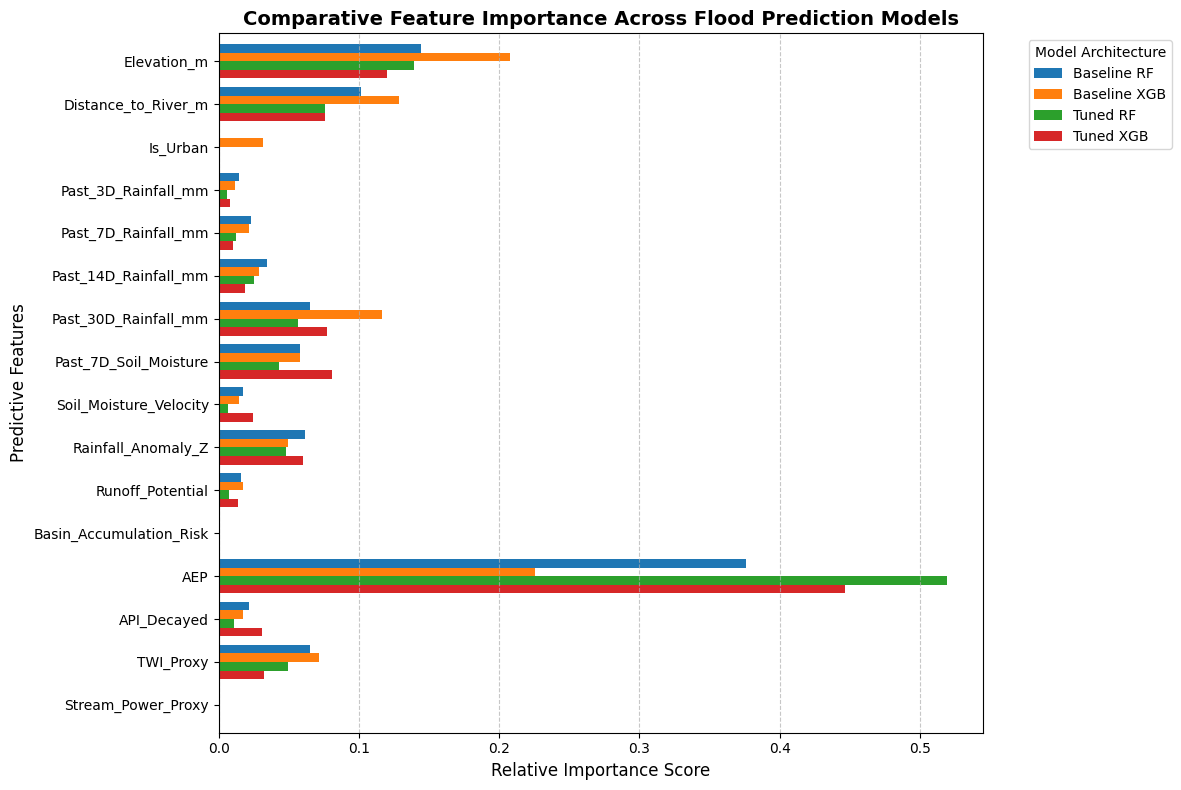

In [143]:
print("--- Extracting Feature Importances Across All Models ---")

# Ensure feature_cols and trained models are defined in your current environment
# (rf_baseline, xgb_baseline, best_tuned_rf, best_tuned_xgb, ensemble_model)

importance_dict = {}

# 1. Baseline Random Forest
if 'rf_base' in globals():
    importance_dict['Baseline RF'] = rf_base.feature_importances_

# 2. Baseline XGBoost
if 'xgb_base' in globals():
    importance_dict['Baseline XGB'] = xgb_base.feature_importances_

# 3. Fine-Tuned Random Forest
if 'best_rf' in globals():
    importance_dict['Tuned RF'] = best_rf.feature_importances_

# 4. Fine-Tuned XGBoost
if 'best_xgb' in globals():
    importance_dict['Tuned XGB'] = best_xgb.feature_importances_

# 5. Ensemble (Averaged importance of its underlying components if available)
if 'master_ensemble' in globals():
    # VotingClassifier doesn't have a direct feature_importances_ attribute,
    # so we average the importances of its fitted estimators (RF and XGB)
    try:
        rf_imp = master_ensemble.named_estimators_['tuned_rf'].feature_importances_
        xgb_imp = master_ensemble.named_estimators_['tuned_xgb'].feature_importances_
        importance_dict['Master Ensemble (Avg)'] = (rf_imp + xgb_imp) / 2.0
    except Exception as e:
        print(f"Could not calculate direct ensemble feature importance: {e}")

# Build a master DataFrame for comparison
importance_df = pd.DataFrame(importance_dict, index=FEATURE_COLS)

# Normalize each column so importances sum to 1.0 for clean visual comparison
importance_df_normalized = importance_df.div(importance_df.sum(axis=0), axis=1)

# Display tabular rankings
print("\n--- Master Feature Importance Rankings (Normalized) ---")
print(importance_df_normalized.sort_values(by=list(importance_df_normalized.columns)[0], ascending=False).to_string())

# Plotting the comparison
plt.figure(figsize=(12, 8))
importance_df_normalized.plot(kind='barh', figsize=(12, 8), width=0.8)
plt.title("Comparative Feature Importance Across Flood Prediction Models", fontsize=14, fontweight='bold')
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Predictive Features", fontsize=12)
plt.gca().invert_yaxis() # Put most important feature at the top
plt.legend(title="Model Architecture", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Calculating Advanced Evaluation Metrics for Master Ensemble ---
[✓] ROC-AUC Score: 0.9379
[✓] Precision-Recall AUC (PR-AUC): 0.4225
[✓] Matthews Correlation Coefficient (MCC): 0.5577
[✓] Balanced Accuracy: 0.8974


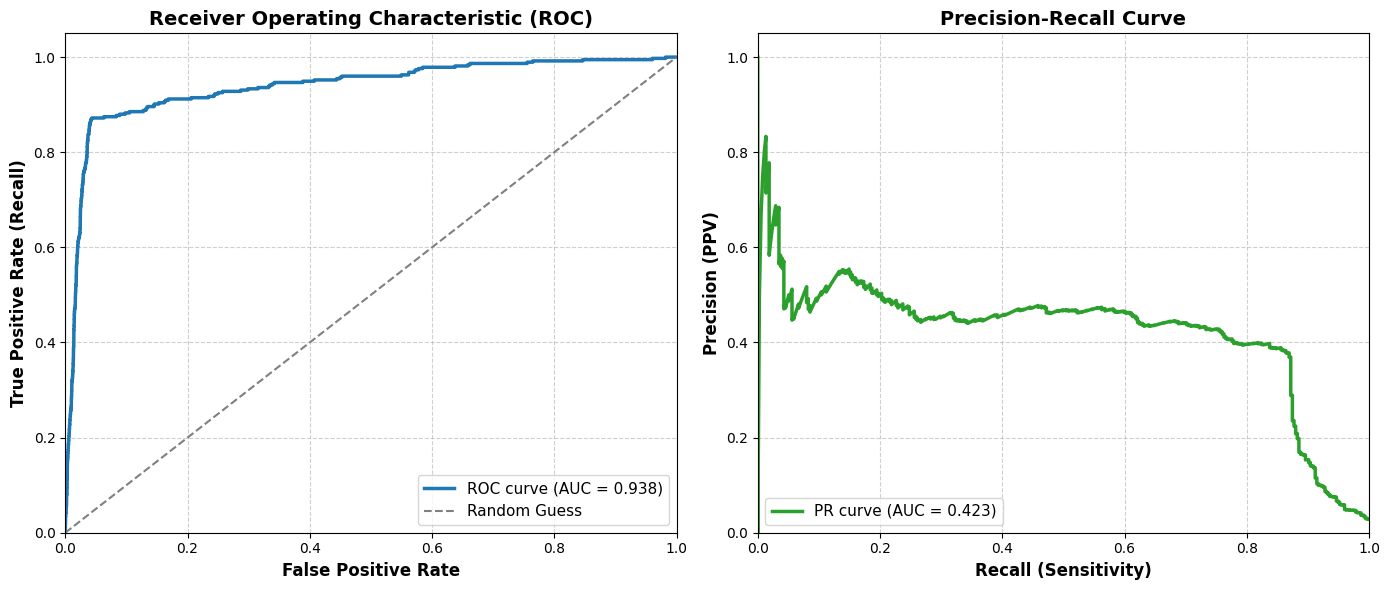

In [145]:
print("--- Calculating Advanced Evaluation Metrics for Master Ensemble ---")

# Ensure master_ensemble, X_test, y_test, and best_thresh are defined in your notebook scope
if 'master_ensemble' in globals() and 'X_test' in globals():
    # Extract predicted probabilities for the positive class (Class 1: Flood Risk)
    probs = master_ensemble.predict_proba(X_test)[:, 1]
    preds = (probs >= best_thresh).astype(int)

    # 1. ROC-AUC Score (Measures model's ability to discriminate between classes overall)
    roc_auc = roc_auc_score(y_test, probs)
    print(f"[✓] ROC-AUC Score: {roc_auc:.4f}")

    # 2. Precision-Recall AUC (PR-AUC) - Highly critical for rare positive events like floods
    pr_auc = average_precision_score(y_test, probs)
    print(f"[✓] Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")

    # 3. Matthews Correlation Coefficient (MCC) - The gold standard metric for imbalanced data (-1 to +1)
    mcc = matthews_corrcoef(y_test, preds)
    print(f"[✓] Matthews Correlation Coefficient (MCC): {mcc:.4f}")

    # 4. Balanced Accuracy (Average of recall obtained on each class)
    bal_acc = balanced_accuracy_score(y_test, preds)
    print(f"[✓] Balanced Accuracy: {bal_acc:.4f}")

    # ==========================================================================
    # VISUALIZING ROC AND PRECISION-RECALL CURVES
    # ==========================================================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ROC Curve Plot
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12, fontweight='bold')
    axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
    axes[0].legend(loc="lower right", fontsize=11)
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Precision-Recall Curve Plot
    precision, recall, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(recall, precision, color='#2ca02c', lw=2.5, label=f'PR curve (AUC = {pr_auc:.3f})')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Precision (PPV)', fontsize=12, fontweight='bold')
    axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    axes[1].legend(loc="lower left", fontsize=11)
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("[!] Error: 'master_ensemble' or 'X_test' not found in global scope. Please run your model training cells first.")

--- Initializing Master Ensemble SHAP Explainability Engine ---
Configuring Explainer for master_ensemble.predict_proba...
Computing SHAP values across test samples (this may take a minute)...


PermutationExplainer explainer: 301it [02:06,  2.37it/s]
/tmp/ipykernel_10844/4197502982.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, eval_subset, plot_type="bar", show=False)


[✓] Ensemble SHAP values successfully calculated!


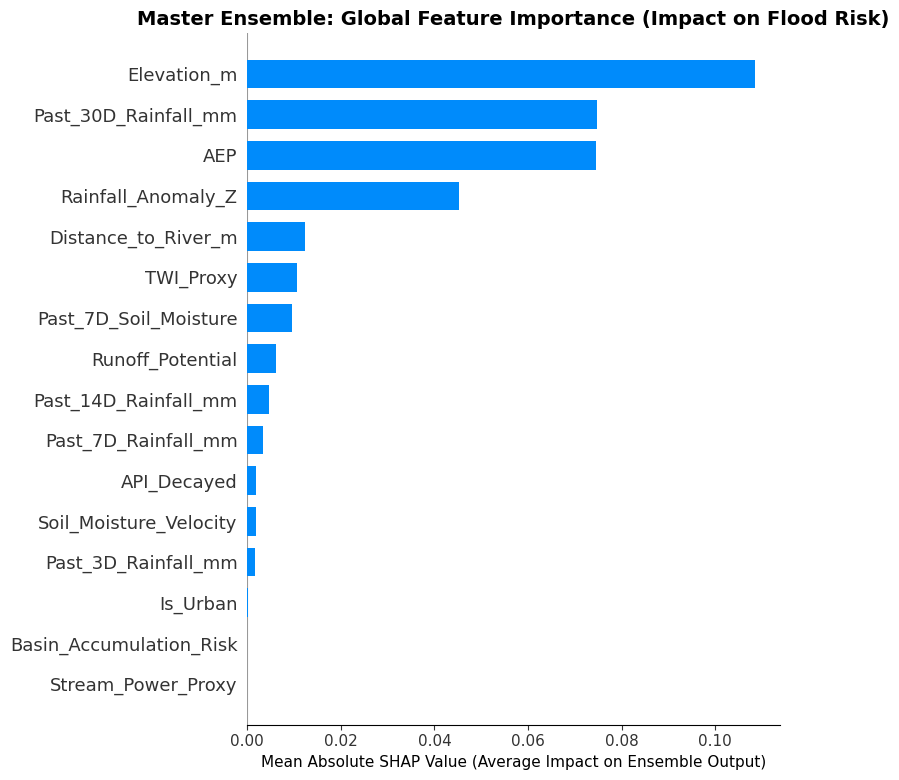

/tmp/ipykernel_10844/4197502982.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, eval_subset, show=False)


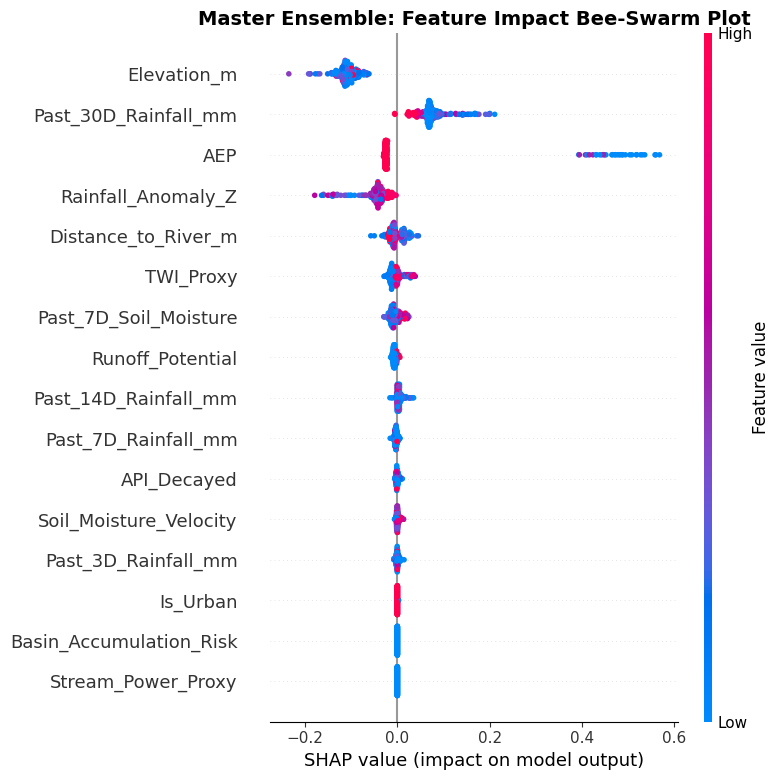


[✓] Generating local waterfall explanation for high-risk ensemble sample index 7...


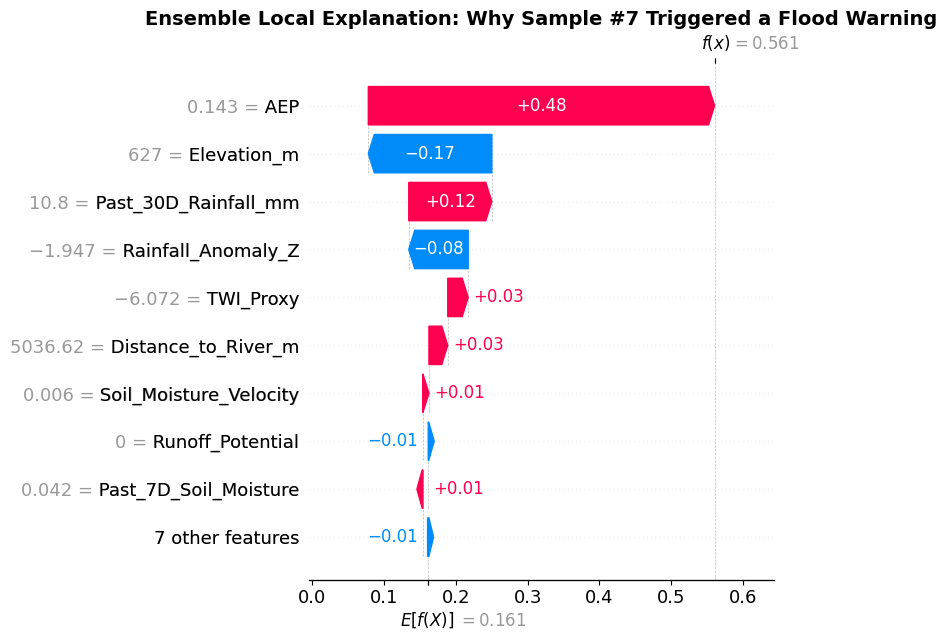


[✓] Master Ensemble SHAP Explainability Analysis Complete!


In [149]:
print("--- Initializing Master Ensemble SHAP Explainability Engine ---")

if 'master_ensemble' not in globals() or 'X_test' not in globals() or 'X_train' not in globals():
    print("[!] Error: 'master_ensemble', 'X_test', or 'X_train' not found in global scope.")
    print("Please ensure your training and test split cells have been executed.")
else:
    print("Configuring Explainer for master_ensemble.predict_proba...")
    # We use a representative background sample (100 rows) from X_train for baseline feature conditioning
    background_data = X_train.sample(100, random_state=42)

    # Define a prediction wrapper returning only the positive class probability (Class 1: Flood Risk)
    predict_fn = lambda x: master_ensemble.predict_proba(x)[:, 1]

    # Note: Evaluated on a subset of X_test (e.g., first 300 rows) for computational efficiency
    print("Computing SHAP values across test samples (this may take a minute)...")
    eval_subset = X_test.iloc[:300].copy()

    # Passing background_data directly lets shap automatically instantiate the appropriate masker
    explainer = shap.Explainer(predict_fn, background_data)
    shap_values = explainer(eval_subset)
    print("[✓] Ensemble SHAP values successfully calculated!")

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, eval_subset, plot_type="bar", show=False)
    plt.title("Master Ensemble: Global Feature Importance (Impact on Flood Risk)", fontsize=14, fontweight='bold')
    plt.xlabel("Mean Absolute SHAP Value (Average Impact on Ensemble Output)", fontsize=11)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, eval_subset, show=False)
    plt.title("Master Ensemble: Feature Impact Bee-Swarm Plot", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    if 'y_test' in globals():
        subset_y = y_test.iloc[:300]
        ensemble_probs = master_ensemble.predict_proba(eval_subset)[:, 1]
        high_risk_indices = np.where((subset_y == 1) & (ensemble_probs >= 0.48))[0]

        if len(high_risk_indices) > 0:
            sample_idx = high_risk_indices[0]
            print(f"\n[✓] Generating local waterfall explanation for high-risk ensemble sample index {sample_idx}...")

            plt.figure(figsize=(10, 6))
            shap.plots.waterfall(shap_values[sample_idx], show=False)
            plt.title(f"Ensemble Local Explanation: Why Sample #{sample_idx} Triggered a Flood Warning", fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        else:
            print("\n[✓] Generating waterfall explanation for the first test sample...")
            plt.figure(figsize=(10, 6))
            shap.plots.waterfall(shap_values[0], show=False)
            plt.title("Ensemble Local Explanation: Sample #0 Prediction Breakdown", fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

    print("\n[✓] Master Ensemble SHAP Explainability Analysis Complete!")

# Deploy

In [150]:

DEPLOY_PATH = "/content/drive/MyDrive/Flood_Predictor_Data/deployed_flood_model.joblib"

deployment_package = {
    'model': master_ensemble,
    'threshold': best_thresh,
    'features': FEATURE_COLS
}

joblib.dump(deployment_package, DEPLOY_PATH)

['/content/drive/MyDrive/Flood_Predictor_Data/deployed_flood_model.joblib']